In [1]:
import numpy as np
from scipy.io import loadmat
import ipywidgets as widgets
from scipy.signal import resample
import os 

import matplotlib.pyplot as plt
from ipywidgets import IntRangeSlider, VBox, HBox, Output,Label
from IPython.display import display, Audio

%matplotlib widget
def procesar_senales(idx_ini, idx_fin, fs_original, MBK, ACC, OVV, EGG, fs_target=8000, ventana_ms=50):
    """
    Recorta las señales entre idx_ini e idx_fin, las resamplea a fs_target
    y las divide en ventanas de ventana_ms milisegundos.
    
    Parámetros:
    -----------
    idx_ini : int
        Índice inicial de recorte
    idx_fin : int
        Índice final de recorte
    fs_original : int
        Frecuencia de muestreo original de las señales
    MBK, ACC, OVV, EGG : np.ndarray
        Señales originales
    fs_target : int, opcional
        Frecuencia de muestreo destino (default=8000 Hz)
    ventana_ms : int, opcional
        Duración de cada ventana en milisegundos (default=50 ms)
    
    Retorna:
    --------
    dict con las señales divididas en ventanas:
        {
          'MBK': [ventana1, ventana2, ...],
          'ACC': [...],
          'OVV': [...],
          'EGG': [...]
        }
    """
    
    # Recorte
    MBK_cut = MBK[idx_ini:idx_fin]
    ACC_cut = ACC[idx_ini:idx_fin]
    OVV_cut = OVV[idx_ini:idx_fin]
    EGG_cut = EGG[idx_ini:idx_fin]
    
    # Número de muestras en la señal recortada
    n_samples = idx_fin - idx_ini
    
    # Número de muestras después del resample
    n_samples_resampled = int(n_samples * fs_target / fs_original)
    
    # Resampleo
    MBK_res = resample(MBK_cut, n_samples_resampled)
    ACC_res = resample(ACC_cut, n_samples_resampled)
    OVV_res = resample(OVV_cut, n_samples_resampled)
    EGG_res = resample(EGG_cut, n_samples_resampled)
    
    # Tamaño de ventana en muestras
    ventana_samples = int(fs_target * ventana_ms / 1000)
    
    def dividir_en_ventanas(signal, ventana_samples):
        n = len(signal)
        return [signal[i:i+ventana_samples] for i in range(0, n, ventana_samples) if len(signal[i:i+ventana_samples]) == ventana_samples]
    
    # División en ventanas
    resultado = {
        'MBK': dividir_en_ventanas(MBK_res, ventana_samples),
        'ACC': dividir_en_ventanas(ACC_res, ventana_samples),
        'OVV': dividir_en_ventanas(OVV_res, ventana_samples),
        'EGG': dividir_en_ventanas(EGG_res, ventana_samples)
    }
    
    return resultado

def guardar_ventanas(ventanas_dict, ruta, nombre_base):
    """
    Guarda cada ventana como archivo .txt con columnas MBK, ACC, OVV, EGG.
    
    Parámetros:
    -----------
    ventanas_dict : dict
        Diccionario con listas de ventanas, como el que devuelve procesar_senales().
        Ejemplo: {'MBK': [...], 'ACC': [...], 'OVV': [...], 'EGG': [...]}
    ruta : str
        Carpeta donde se guardarán los archivos
    nombre_base : str
        Nombre base de los archivos. Se le adjunta el índice de la ventana.
        Ejemplo: 'ventana' -> ventana_1.txt, ventana_2.txt, ...
    """
    os.makedirs(ruta, exist_ok=True)
    
    n_ventanas = len(ventanas_dict['MBK'])
    
    for i in range(n_ventanas):
        mbk_win = ventanas_dict['MBK'][i]
        acc_win = ventanas_dict['ACC'][i]
        ovv_win = ventanas_dict['OVV'][i]
        egg_win = ventanas_dict['EGG'][i]
        
        matriz = np.column_stack([mbk_win, acc_win, ovv_win, egg_win])
        
        filename = os.path.join(ruta, f"{nombre_base}_{i+1}.txt")
        
        np.savetxt(filename, matriz, fmt="%.6f", delimiter="\t",
                   header="MBK\tACC\tOVV\tEGG", comments='')




In [2]:
ruta = r"G:\Mi unidad\Facultad\Beca CIN\NNMF-GIF\Repositorio AC3E\Controles\FN006\R02 - Calibrated Gestures\vowels.mat"

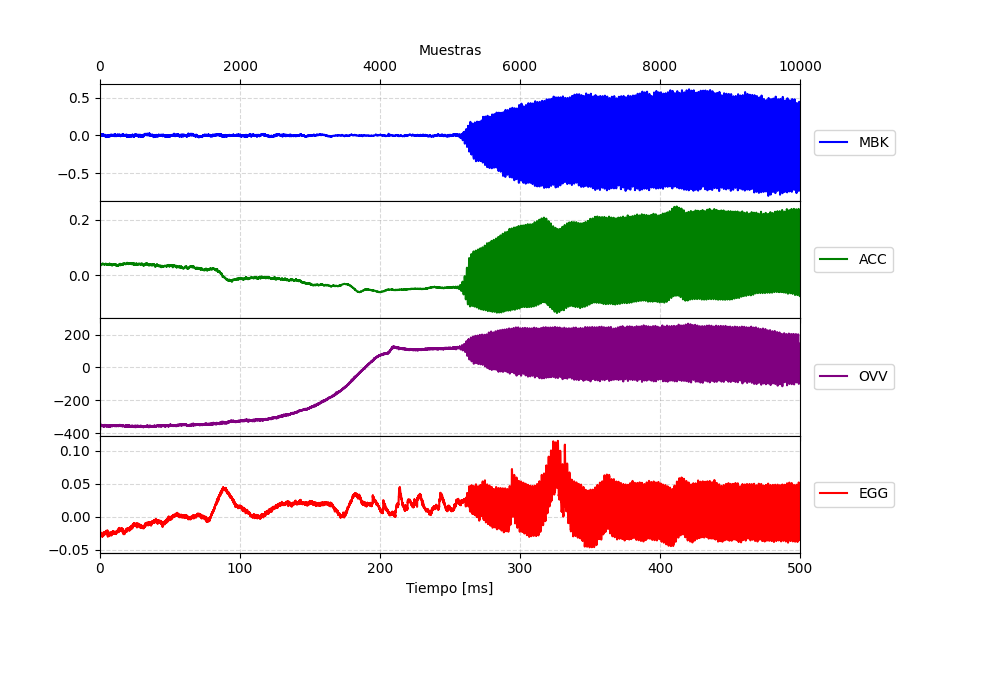

In [3]:

mat_contents = loadmat(ruta, squeeze_me=True)
fs = 20000
min_range = 600
MBK = mat_contents["MBK"]["data"]
MBK_ = MBK / np.max(np.abs(MBK))
ACC = mat_contents["ACC"]["data"][()]
OVV = mat_contents["OVV"]["data"][()]
EGG = mat_contents["EGG"]["data"][()]


def MuestrasTiempo(muestras):
    return muestras * 1000 / fs


def TiempoMuestras(tiempo):
    return np.round(tiempo * fs / 1000)


fig, ax = plt.subplots(4, 1, figsize=(10, 7))
fig.canvas.header_visible = False
fig.subplots_adjust(left=0.1, right=0.80)
audio_out = Output(layout=widgets.Layout(width="75%"))


def f(x):
    if x[1] - x[0] > min_range:
        for a in ax:
            a.clear()

        muestras = np.arange(x[0], x[1])

        señal_MBK = MBK_[x[0] : x[1]]
        ax[0].plot(muestras, señal_MBK, color="blue", label="MBK")
        ax[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
        ax[0].grid(True, linestyle="dashed", color="gray", alpha=0.3, which="both")
        ax[0].set_xlim(x[0], x[1])
        #sec = ax[0].secondary_xaxis("top", functions=(MuestrasTiempo, TiempoMuestras))
        #sec.set_xlabel("Tiempo [ms]")
        # Eje superior: muestras
        ax[0].set_xlabel("Muestras")    # etiqueta arriba
        ax[0].xaxis.set_label_position("top") 
        ax[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False, top=True, labeltop=True)


        señal_ACC = ACC[x[0] : x[1]]
        ax[1].plot(muestras, señal_ACC, color="green", label="ACC")
        ax[1].grid(True, linestyle="dashed", color="gray", alpha=0.3, which="both")
        ax[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
        ax[1].set_xlim(x[0], x[1])
        ax[1].tick_params(axis='x', which='both',labelbottom=False)
        pos1 = ax[0].get_position()
        pos2 = ax[1].get_position()
        ax[1].set_position([pos2.x0, pos1.y0 - pos2.height, pos2.width, pos2.height])

        señal_OVV = OVV[x[0] : x[1]]
        ax[2].plot(muestras, señal_OVV, color="purple", label="OVV")
        ax[2].grid(True, linestyle="dashed", color="gray", alpha=0.3, which="both")
        ax[2].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
        ax[2].grid(True, linestyle="dashed", color="gray", alpha=0.3, which="both")
        ax[2].set_xlim(x[0], x[1])
        ax[2].tick_params(axis='x', which='both',labelbottom=False)
        pos3 = ax[1].get_position()
        pos4 = ax[2].get_position()
        ax[2].set_position([pos4.x0, pos3.y0 - pos4.height, pos4.width, pos4.height])

        señal_EGG = EGG[x[0] : x[1]]
        ax[3].plot(muestras, señal_EGG, color="red", label="EGG")

        # Fijar límites del eje principal
        ax[3].set_xlim(x[0], x[1])

        # Ocultar ticks y etiqueta del eje principal inferior
        ax[3].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

        # Eje secundario inferior: tiempo en ms
        sec = ax[3].secondary_xaxis("bottom", functions=(MuestrasTiempo, TiempoMuestras))
        sec.set_xlabel("Tiempo [ms]")
        ax[3].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
        ax[3].grid(True, linestyle="dashed", color="gray", alpha=0.3, which="both")
        pos5 = ax[2].get_position()
        pos6 = ax[3].get_position()
        ax[3].set_position([pos6.x0, pos5.y0 - pos6.height, pos6.width, pos6.height])

        audio_out.clear_output()
        fig.canvas.draw()

        with audio_out:
            display(Audio(señal_MBK, rate=fs, autoplay=True))


slider = IntRangeSlider(
    value=[0, 10000],
    min=0,
    max=len(MBK_),
    step=1,
    description="Muestras:",
    continuous_update=False,
    orientation="horizontal",
    readout=True,
    readout_format="d",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="70%"),
)
# Label para mostrar duración en ms
duration_label = Label()

def update_duration(change):
    x0, x1 = change['new']
    if x1 - x0 > min_range:
        dur_ms = (x1 - x0) * 1000 / fs
        duration_label.value = f"  |   Duración: {dur_ms:.1f} ms"

# Conectar el slider al label
slider.observe(update_duration, names='value')

# Inicializar el label con el valor inicial
update_duration({'new': slider.value})

out = widgets.interactive_output(f, {'x': slider})

ui = VBox([
    out,
    HBox([slider, duration_label], layout=widgets.Layout(width='100%')),
    HBox([audio_out], layout=widgets.Layout(width='100%'))
])

display(ui);


In [4]:
#ventanas = procesar_senales(50000, 61000, fs, MBK_, ACC, OVV, EGG)
#guardar_ventanas(ventanas, ruta="Señales AC3E\\Femenino", nombre_base="FN007_A")
#print(f"Número de ventanas: {len(ventanas['MBK'])}")
#print(f"Tamaño de cada ventana: {len(ventanas['MBK'][0])} muestras")
